In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterstats as rs
import matplotlib.pyplot as plt
import os 
import osmnx as ox
import momepy
from shapely.ops import unary_union
from shapely.geometry import Point, LineString
import networkx as nx
import rasterio as rio 
from rasterio.plot import show
from rasterio.merge import merge

GWR_GDF_PATH = "Data/GWR_Features/strava_gwr_features.gpkg"

# Processing Strava Data

## Count data preprocessing

In [47]:
strava_25_monthly = pd.read_csv("Data/Strava/strava_2025monthly_bankspeninsula_peds.csv")
strava_22_ped = pd.read_csv("Data/Strava/strava_2022_bankspeninsula_peds.csv")
strava_22_cycle = pd.read_csv("Data/Strava/strava_2022_bankspeninsula_cycling.csv")
strava_22_counts = pd.concat([strava_22_ped, strava_22_cycle], ignore_index=True,join='inner', axis=0)
# strava_22_counts = strava_22_ped

In [48]:
#Collate to monthly bins
strava_22_counts['time'] = pd.to_datetime(strava_22_counts['hour'],format='mixed')
strava_22_counts['month'] = strava_22_counts['time'].dt.to_period('M')
strava_22_monthly = strava_22_counts.groupby(['month', 'edge_uid', 'activity_type', 'osm_reference_id']).agg({
    'total_trip_count': 'sum',
    }).reset_index()


In [49]:
strava_monthly_counts = pd.concat([strava_22_monthly, strava_25_monthly], ignore_index=True,join='inner', axis=0)
def classify_strava_activity(activity_type):
    activity_text = "" if pd.isna(activity_type) else str(activity_type).lower()
    pedestrian_keywords = ["walk", "hike", "hiking", "trail", "run", "running", "trek", "parkrun"]
    cycle_keywords = ["cycle", "bike", "biking", "mtb", "mountain", "road", "bmx", "gravel"]

    if any(keyword in activity_text for keyword in cycle_keywords):
        return "cycle"
    if any(keyword in activity_text for keyword in pedestrian_keywords):
        return "pedestrian"
    return "other"

strava_monthly_counts["activity_class"] = strava_monthly_counts["activity_type"].apply(classify_strava_activity)

strava_monthly_counts = strava_monthly_counts.groupby(['edge_uid','month','osm_reference_id', 'activity_class']).agg({
    'total_trip_count': 'sum',
}).reset_index()

strava_monthly_counts.to_csv("Data/Strava/strava_2022_25_monthly_counts.csv", index=False)

In [ ]:
strava_total_counts = strava_monthly_counts.groupby(['edge_uid', 'osm_reference_id', 'activity_class']).agg({
    'total_trip_count': 'sum',
}).reset_index()

strava_total_counts.to_csv("Data/Strava/strava_2022_25_total_counts.csv", index=False)

## Mapping to geometry

In [107]:
strava_total_counts = pd.read_csv("Data/Strava/strava_2022_25_total_counts.csv")
strava_id_map = gpd.read_file("Data/Strava/strava_bikeped_osm.gpkg").to_crs(epsg=2193)
strava_gwr_features = strava_id_map.merge(strava_total_counts, left_on='edgeUID', right_on='edge_uid', how='left')
strava_gwr_features.drop(columns=['edge_uid', 'osm_reference_id', 'activity_class'], inplace=True)
strava_gwr_features.explode().to_file(GWR_GDF_PATH, driver="GPKG")

## Plotting

<Axes: xlabel='month'>

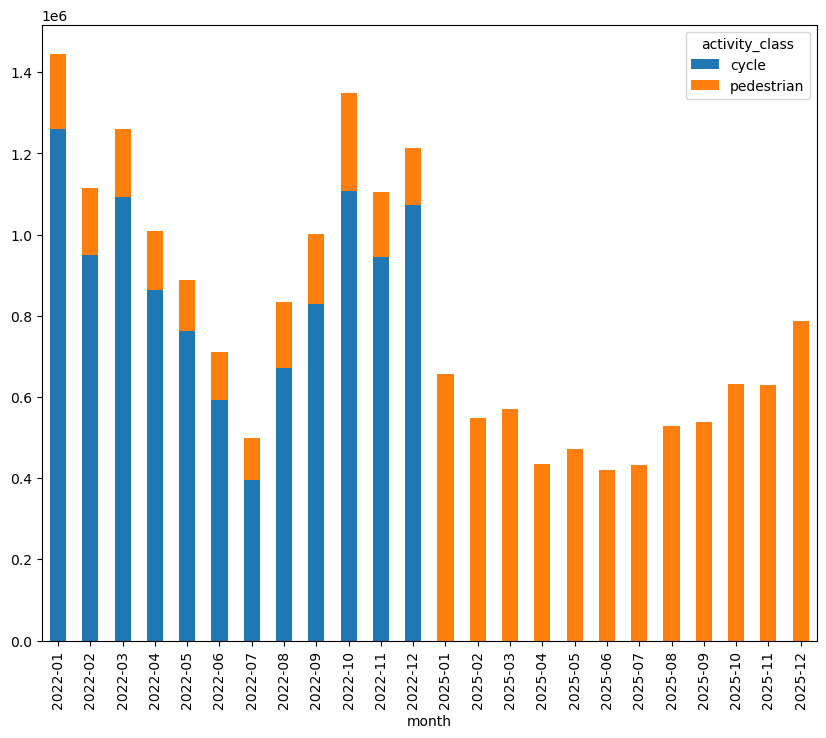

In [52]:
fig, ax = plt.subplots(figsize=(10, 8))
strava_monthly_counts.groupby(['month', 'activity_class'])['total_trip_count'].sum().unstack().plot(kind='bar', stacked=True, ax=ax)

# Building Features

## DEM Features

### DEM Tile Merge

In [ ]:
data_dir = "Data/GWR_Features/DEM"

tile_names = ["PH.tif", "PI.tif", "QH.tif", "QI.tif"]
file_paths = [os.path.join(data_dir, tile) for tile in tile_names]

src_files_to_mosaic = []
for fp in file_paths:
    src = rio.open(fp)
    src_files_to_mosaic.append(src)

mosaic, out_trans = merge(src_files_to_mosaic)

out_meta = src_files_to_mosaic[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans
})

output_fp = os.path.join(data_dir, "merged_nz_dem.tif")
with rio.open(output_fp, "w", **out_meta) as dest:
    dest.write(mosaic)

for src in src_files_to_mosaic:
    src.close()

print(f"Successfully merged {len(tile_names)} tiles into: {output_fp}")


Successfully merged 4 tiles into: Data/Supplementaries/kx-nz-8m-digital-elevation-model-2012-GTiff\merged_nz_dem.tif


### Zonal Statistics 

In [109]:
strava_gwr_features = gpd.read_file(GWR_GDF_PATH).to_crs(epsg=2193)
strava_gwr_features['buff_geometry'] = strava_gwr_features.geometry.buffer(5)

with rio.open("Data/GWR_Features/kx-nz-8m-digital-elevation-model-2012-GTiff/merged_nz_dem.tif") as DEM_src:
    print("DEM CRS:", DEM_src.crs)
    dem_array = DEM_src.read(1)
    dem_array.clip(min=0, out=dem_array)
    elevation_stats = rs.zonal_stats(
        strava_gwr_features['buff_geometry'], 
        dem_array, 
        affine=DEM_src.transform, 
        stats=[ 
            'max',
            'range'])
strava_gwr_features['elevation_range'] = [stat['range'] for stat in elevation_stats]
strava_gwr_features['elevation_max'] = [stat['max'] for stat in elevation_stats]
strava_gwr_features['gradient'] = strava_gwr_features['elevation_range'] / strava_gwr_features.geometry.length

strava_gwr_features['gradient'] = strava_gwr_features['gradient'].clip(upper=1)
strava_gwr_features.drop(columns=['buff_geometry'], inplace=True)
strava_gwr_features.to_file(GWR_GDF_PATH, layer='strava_gwr_features', driver="GPKG")


DEM CRS: EPSG:2193


###  Plotting

<Axes: >

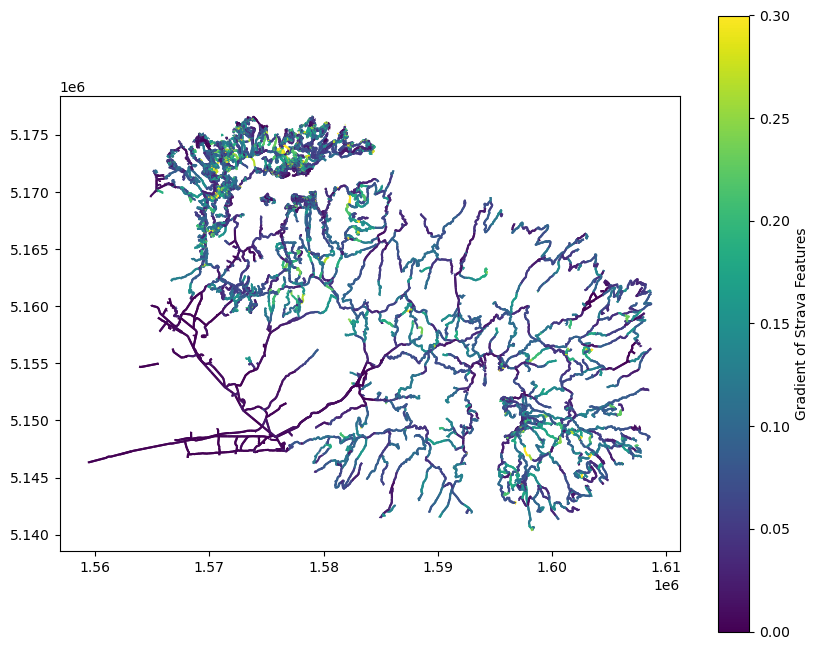

In [92]:
strava_gwr_features.plot(column='gradient',vmax=0.3, cmap='viridis', legend=True, legend_kwds={'label': 'Gradient of Strava Features'},figsize=(10, 8))

<Axes: >

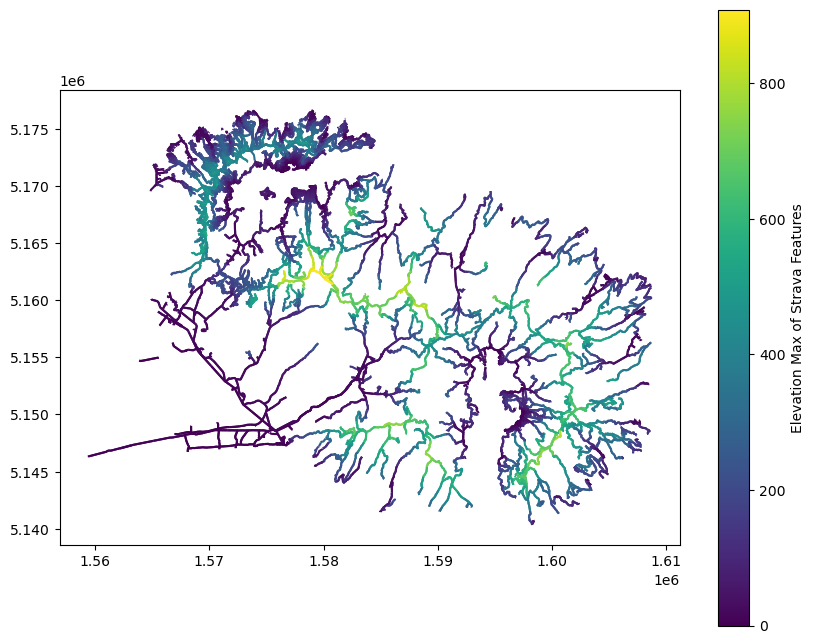

In [97]:
strava_gwr_features.plot(column='elevation_max', cmap='viridis', legend=True, legend_kwds={'label': 'Elevation Max of Strava Features'},figsize=(10, 8))

<Axes: >

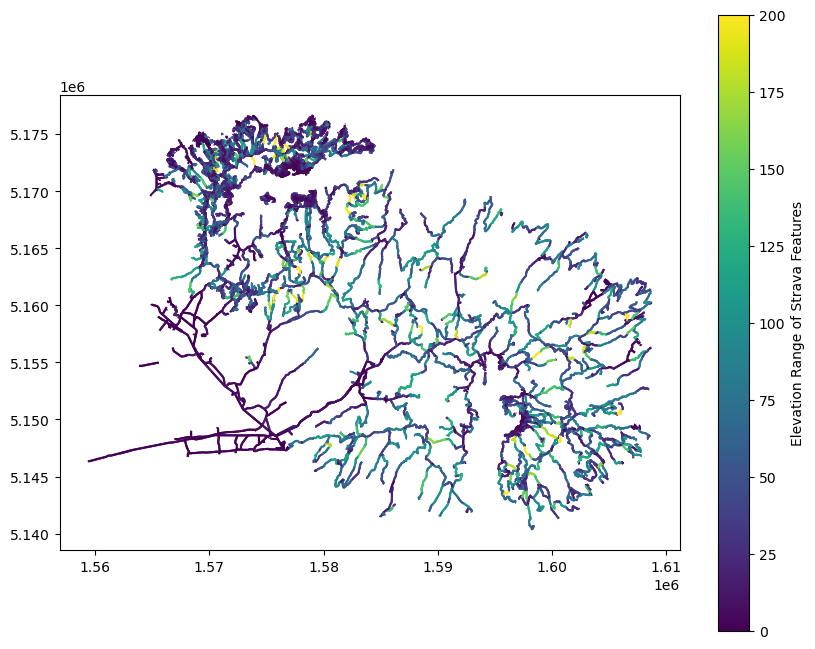

In [98]:
strava_gwr_features.plot(column='elevation_range',vmax=200, cmap='viridis', legend=True, legend_kwds={'label': 'Elevation Range of Strava Features'},figsize=(10, 8))

## Network Features

### Loading highway types

In [111]:
# 1. Load your existing data
strava_gwr_features = gpd.read_file(GWR_GDF_PATH).to_crs(epsg=2193)

# 2. Filter out empty geometries to ensure clean coordinates
valid_features = strava_gwr_features[strava_gwr_features.geometry.notna() & ~strava_gwr_features.geometry.is_empty]

# 3. Convert to Lat/Lon (EPSG:4326)
strava_4326 = valid_features.to_crs(epsg=4326)

# total_bounds natively returns [minx, miny, xmax, ymax]
# This perfectly translates to [left, bottom, right, top] / [min_lon, min_lat, max_lon, max_lat]
left, bottom, right, top = strava_4326.total_bounds


# 4. Download the features using the standardized modern tuple format
print("Downloading all OSM features within the bounding box...")
osm_features = ox.features_from_bbox(
    bbox=(left, bottom, right, top),  # Standardized format
    tags={"highway": True}
)

# 5. Clean up the downloaded OSM data for a tabular ID merge
osm_ways = osm_features.reset_index()
osm_ways_clean = osm_ways[['id', 'highway']].copy()

# 6. Ensure data types are aligned for the merge (convert IDs to integers)
osm_ways_clean['osmId'] = osm_ways_clean['id'].astype(int)
strava_gwr_features['osmId'] = strava_gwr_features['osmId'].dropna().astype(int)

# 7. Relational Merge: Match explicitly on the IDs (not proximity)
print("Merging datasets exactly by OSM ID...")
strava_gwr_features = strava_gwr_features.merge(
    osm_ways_clean,
    left_on='osmId',
    right_on='osmId',
    how='left'
).drop(columns=['osmId'])

print("Done! Highway types successfully mapped by ID.")

Merging datasets exactly by OSM ID...
Done! Highway types successfully mapped by ID.


### Classifying Roads

<Axes: >

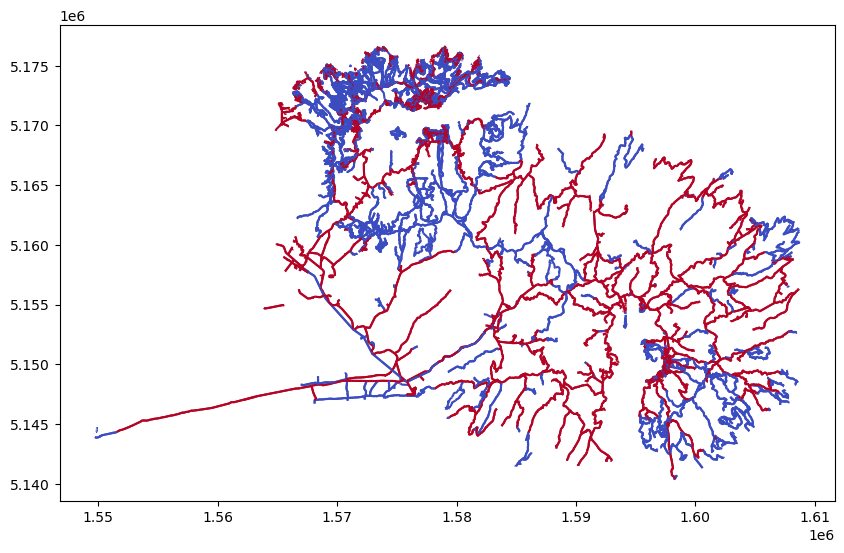

In [112]:
def classify_road(highway_type):
    if pd.isna(highway_type):
        return False 
    highway_text = str(highway_type).lower()
    road_tags = ["primary", "secondary", "tertiary", "residential", 
                 "unclassified", "trunk","trunk_link", "motorway", 
                 "service", "living_street", "raceway", "secondary_link", "construction"]
    if any(keyword in highway_text for keyword in road_tags):
        return True
    return False

strava_gwr_features["road"] = strava_gwr_features["highway"].apply(classify_road)
strava_gwr_features.to_file(GWR_GDF_PATH, driver="GPKG")
strava_gwr_features.plot(column='road', cmap='coolwarm', figsize=(10, 8))

### Form Network

In [6]:
# Now pass it into momepy safely
def network_distance_to_road(strava_gwr_features, source = "ped"):
    G = momepy.gdf_to_nx(strava_gwr_features[strava_gwr_features["source"]==source], approach="primal")


    # 3. Identify target nodes (nodes connected to a road)
    road_nodes = set()
    for u, v, data in G.edges(data=True):
        # Check if this edge is labeled as a road
        if data.get("road") == True or data.get("road") == "True":
            road_nodes.add(u)
            road_nodes.add(v)


    # 4. Multi-source Dijkstra: Calculate distance from ALL nodes to the NEAREST road node
    # 'weight' uses the geometry length calculated by momepy
    road_distances = nx.multi_source_dijkstra_path_length(G, sources=road_nodes, weight="mm_len")
    # --- STEP 5: Map via a Geometry -> Distance Dictionary ---
    uid_to_dist = {}

    # We use keys=True to safely unpack a MultiGraph if momepy generated one
    for u, v,key, data in G.edges(keys=True, data=True):
        if data.get('road') == True:
            edge_dist = 0.0
        else:
            # Distance is the minimum network distance of its two endpoints
            dist_u = road_distances.get(u, np.inf)
            dist_v = road_distances.get(v, np.inf)
            edge_dist = min(dist_u, dist_v)
        
        # Store using edgeUID as the unique key
        uid_to_dist[data['edgeUID']] = edge_dist
    return uid_to_dist



### Find network distances to roads

In [21]:

strava_gwr_features = gpd.read_file(GWR_GDF_PATH).to_crs(epsg=2193)
strava_gwr_features = strava_gwr_features.explode(index_parts=False, ignore_index=True)

# Extract only rows where the geometry is strictly a LineString
strava_gwr_features = strava_gwr_features[strava_gwr_features.geometry.geom_type == 'LineString']

# Remove empty geometries
strava_gwr_features = strava_gwr_features[~strava_gwr_features.geometry.is_empty]
ped_distances = network_distance_to_road(strava_gwr_features, source = "ped")
bike_distances = network_distance_to_road(strava_gwr_features, source = "bike")
merge_distances = {**bike_distances, **ped_distances}  # Merge dictionaries, bike distances will overwrite ped distances if keys collide
# --- STEP 6: Map Directly onto your original DataFrame ---
# Map using the 'edgeUID' column instead of lambda geometry matching
strava_gwr_features['distance_to_road'] = strava_gwr_features['edgeUID'].map(merge_distances).fillna(np.inf)

# Clip and save
strava_gwr_features['distance_to_road'] = strava_gwr_features['distance_to_road'].clip(upper=10000)
strava_gwr_features.to_file("Data/Strava/strava_gwr_features.gpkg", driver="GPKG")

# Quick sanity check
print("Distance Summary:")
print(strava_gwr_features['distance_to_road'].describe())

Distance Summary:
count    23401.000000
mean       431.642404
std       1398.467787
min          0.000000
25%          0.000000
50%          0.000000
75%        195.204004
max      10000.000000
Name: distance_to_road, dtype: float64


### Plotting

In [25]:
strava_gwr_features_bike = strava_gwr_features[strava_gwr_features['source'] == 'bike']
strava_gwr_features_ped = strava_gwr_features[strava_gwr_features['source'] == 'ped']

array([[<Axes: title={'center': 'distance_to_road'}>]], dtype=object)

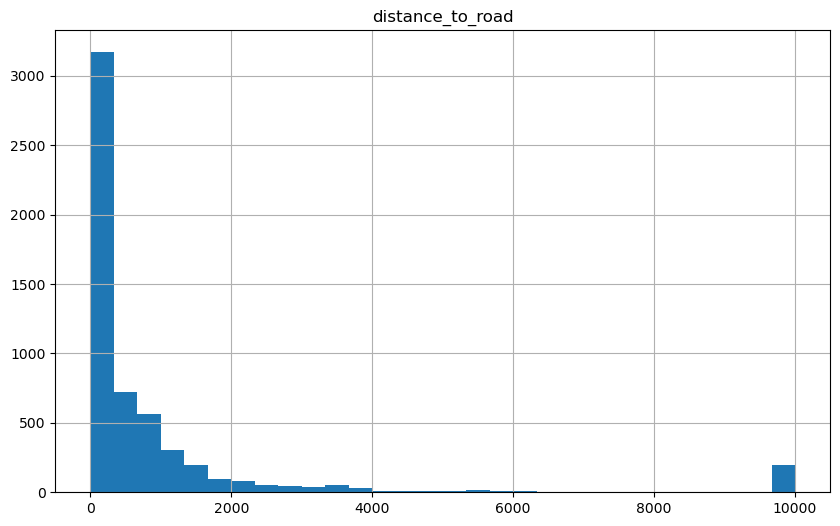

In [24]:
strava_gwr_features_bike[strava_gwr_features_bike['road'] == False].hist(column='distance_to_road', bins=30, figsize=(10, 6))

<Axes: >

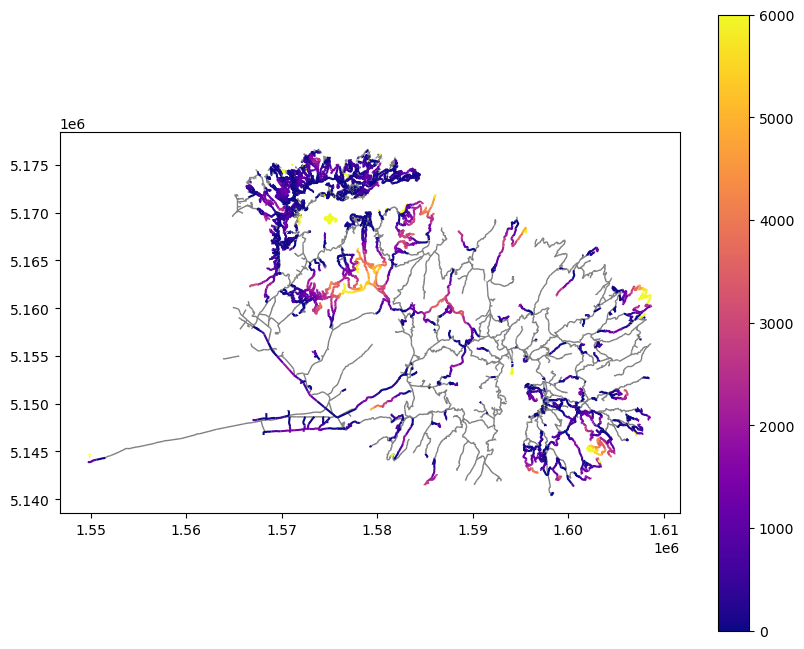

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
strava_gwr_features_bike[strava_gwr_features_bike['road'] == True].plot(color='gray', linewidth=1, ax=ax)
strava_gwr_features_bike[strava_gwr_features_bike['road'] == False].plot(column='distance_to_road', vmax = 6000, cmap='plasma', legend=True, figsize=(10, 8), ax=ax)


### Finding Network Distance to Urban Areas

In [2]:
def distance_to_urban(strava_gwr_features, urban_rural_polygon, urban_threshold = 21):
    urban_polygons = urban_rural_polygon[urban_rural_polygon['IUR2026_V1'] <= urban_threshold].geometry.union_all()
    distance_dict = {}
    for source in strava_gwr_features['source'].unique():
        urban_nodes = set()
        source_features = strava_gwr_features[strava_gwr_features['source'] == source]
        G = momepy.gdf_to_nx(source_features, approach="primal")

        for u, v, data in G.edges(data=True):
            if data.get("road") == True:
                # 2. Get the geometry attribute of the nodes from G.nodes
                u_att = G.nodes[u]
                v_att = G.nodes[v]

                u_geom = Point(u_att['x'], u_att['y'])
                v_geom = Point(v_att['x'], v_att['y'])

                if u_geom.within(urban_polygons):
                    urban_nodes.add(u)
                if v_geom.within(urban_polygons):
                    urban_nodes.add(v)

        if not urban_nodes:
            distance_dict[source] = {}
            continue

        urban_distances = nx.multi_source_dijkstra_path_length(
            G,
            sources=urban_nodes,
            weight="mm_len"
        )
        uid_to_dist = {}

        # We use keys=True to safely unpack a MultiGraph if momepy generated one
        for u, v,key, data in G.edges(keys=True, data=True):
            if u in urban_nodes or v in urban_nodes:
                edge_dist = 0.0
            else:
                # Distance is the minimum network distance of its two endpoints
                dist_u = urban_distances.get(u, np.inf)
                dist_v = urban_distances.get(v, np.inf)
                edge_dist = min(dist_u, dist_v)
            
            # Store using edgeUID as the unique key
            uid_to_dist[data['edgeUID']] = edge_dist
        distance_dict[source] = uid_to_dist
        
    return {**distance_dict.get('bike', {}), **distance_dict.get('ped', {})}  # Bike distances are overwritten by ped distances if keys collide

In [3]:
strava_gwr_features = gpd.read_file("Data/Strava/strava_gwr_features.gpkg")
urban_rural_polygon = gpd.read_file("Data/GWR_Features/statsnz-urban-rural-2026-SHP/urban-rural-2026.shp").to_crs(epsg=2193)
urban_rural_polygon = urban_rural_polygon.drop(columns=['UR2026_V_2', 'LAND_AREA_', 'AREA_SQ_KM', 'Shape_Leng'])
urban_rural_polygon = urban_rural_polygon.explode(ignore_index=True)
urban_rural_polygon['IUR2026_V1'] = urban_rural_polygon['IUR2026_V1'].astype(int)

# urban_rural_polygon["Rural_settlement"] = urban_rural_polygon['IUR2026_V1'] <= 21
# urban_rural_polygon["Small urban area"] = urban_rural_polygon['IUR2026_V1'] <= 14
# urban_rural_polygon["Medium urban area"] = urban_rural_polygon['IUR2026_V1'] <= 13
# urban_rural_polygon["Major_urban_area"] = urban_rural_polygon['IUR2026_V1'] <= 11

Rural_settlement_distances = distance_to_urban(strava_gwr_features, urban_rural_polygon, urban_threshold=21)
strava_gwr_features['Rural_settlement_distances'] = strava_gwr_features['edgeUID'].map(Rural_settlement_distances).fillna(np.inf)

Rural_settlement_distances = distance_to_urban(strava_gwr_features, urban_rural_polygon, urban_threshold=14)
strava_gwr_features['Small_urban_distances'] = strava_gwr_features['edgeUID'].map(Rural_settlement_distances).fillna(np.inf)

Rural_settlement_distances = distance_to_urban(strava_gwr_features, urban_rural_polygon, urban_threshold=13)
strava_gwr_features['Medium_urban_distances'] = strava_gwr_features['edgeUID'].map(Rural_settlement_distances).fillna(np.inf)

Rural_settlement_distances = distance_to_urban(strava_gwr_features, urban_rural_polygon, urban_threshold=11)
strava_gwr_features['Major_urban_distances'] = strava_gwr_features['edgeUID'].map(Rural_settlement_distances).fillna(np.inf)

strava_gwr_features.to_file("Data/Strava/strava_gwr_features.gpkg", driver="GPKG")

# Quick sanity check
print("Distance Summary:")
print(strava_gwr_features['Rural_settlement_distances'].describe())

Distance Summary:
count    2.340100e+04
mean              inf
std               NaN
min      0.000000e+00
25%      0.000000e+00
50%      5.032077e+02
75%      3.706288e+03
max               inf
Name: Rural_settlement_distances, dtype: float64


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


### Plotting

<Axes: >

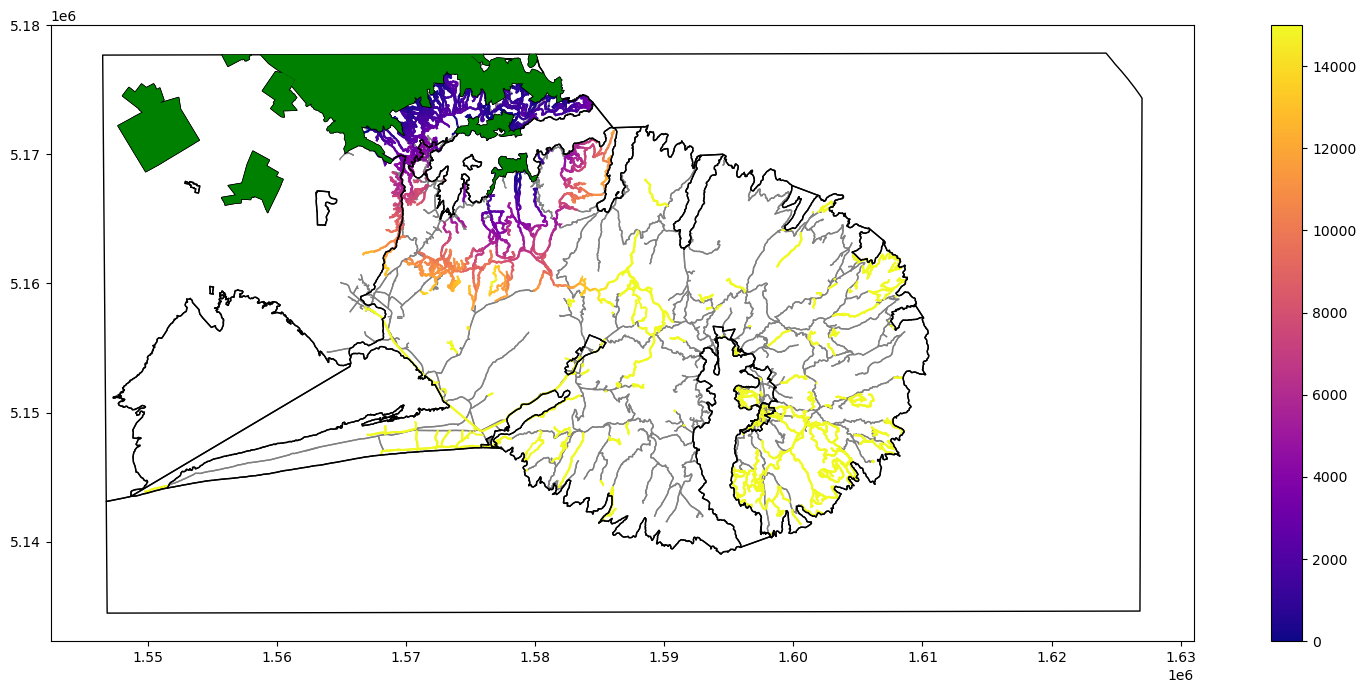

In [7]:
fig, ax = plt.subplots(figsize=(20, 8))
strava_gwr_features[strava_gwr_features['road'] == True].plot(color='gray', linewidth=1, ax=ax)
strava_gwr_features[strava_gwr_features['road'] == False].plot(column='Small_urban_distances', vmax=15000, cmap='plasma', legend=True, figsize=(20, 8), ax=ax)
urban_rural_polygon.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1,zorder=10)
urban_rural_polygon[urban_rural_polygon['IUR2026_V1'] <= 14].plot(ax=ax, facecolor='green', edgecolor='none', linewidth=1,zorder=10)

## Buffer Features

### Trail Density

In [2]:
strava_gwr_features = gpd.read_file(GWR_GDF_PATH).to_crs(epsg=2193)


In [6]:
def calculate_trail_density(strava_gwr_features, buffer_distance):
    strava_gwr_features = strava_gwr_features.copy()
    buffer_column_name = f'buffer_{buffer_distance}m'
    strava_gwr_features[buffer_column_name] = strava_gwr_features.geometry.buffer(buffer_distance)

    road_mask = strava_gwr_features['road'] == True
    trail_mask = ~road_mask

    strava_gwr_features.loc[road_mask, 'trail_length_within_buffer'] = 0
    strava_gwr_features.loc[trail_mask, 'trail_length_within_buffer'] = strava_gwr_features.loc[trail_mask].apply(
        lambda row: strava_gwr_features[strava_gwr_features.geometry.intersects(row[buffer_column_name])].geometry.length.sum(),
        axis=1,
    )

    strava_gwr_features['buffer_area'] = strava_gwr_features[buffer_column_name].area

    strava_gwr_features[f'trail_density_{buffer_distance}m'] = (
        strava_gwr_features['trail_length_within_buffer'] / strava_gwr_features['buffer_area']
    )

    strava_gwr_features.drop(columns=['trail_length_within_buffer', 'buffer_area'], inplace=True)
    strava_gwr_features.drop([col for col in strava_gwr_features.columns if col.startswith('buffer_')], axis=1, inplace=True)
    return strava_gwr_features
#---------------------------------------------------------------
strava_gwr_features.drop([col for col in strava_gwr_features.columns if col.startswith('buffer_')], axis=1, inplace=True)

buffers = range(400, 1000, 200)  # Create a range from 400 to 1000 with a step of 200
strava_gwr_features_ped = strava_gwr_features[strava_gwr_features['source'] == 'ped']
strava_gwr_features_bike = strava_gwr_features[strava_gwr_features['source'] == 'bike']

for buffer_distance in buffers:
    strava_gwr_features_ped = calculate_trail_density(strava_gwr_features_ped, buffer_distance)
    strava_gwr_features_bike = calculate_trail_density(strava_gwr_features_bike, buffer_distance)

strava_gwr_features = pd.concat([strava_gwr_features_ped, strava_gwr_features_bike], ignore_index=True)
strava_gwr_features.to_file(GWR_GDF_PATH, driver="GPKG")

#### Plotting

<Axes: >

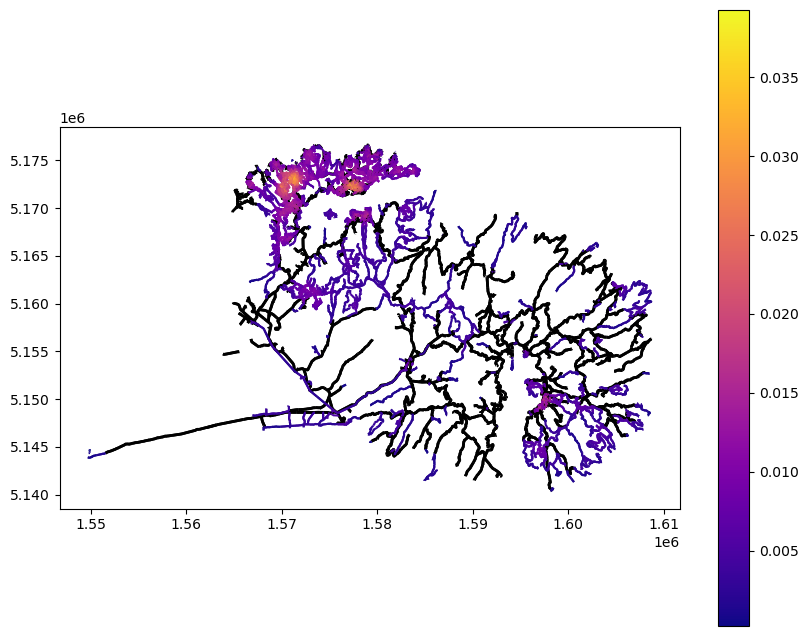

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
road_features = strava_gwr_features[strava_gwr_features['road'] == True]
road_features.plot(ax=ax, color='black', linewidth=2)
strava_gwr_features[strava_gwr_features['road'] == False].plot(column='trail_density_600m', cmap='plasma', legend=True, figsize=(10, 8), ax=ax)

In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString

strava_gwr_features = gpd.GeoDataFrame(
    {
        'source': ['ped', 'ped', 'bike', 'bike'],
        'road': [True, False, True, False],
    },
    geometry=[
        LineString([(0, 0), (10, 0)]),
        LineString([(0, 1), (10, 1)]),
        LineString([(0, 2), (10, 2)]),
        LineString([(0, 3), (10, 3)]),
    ],
    crs='EPSG:2193',
)


### Landcover

In [6]:
landcover = gpd.read_file("Data/GWR_Features/landcover/lcdb-v60-land-cover-database-version-60-mainland-new-zealand.shp").to_crs(epsg=2193)
landcover = landcover[['Name_2023', 'Class_2023', 'geometry']]

In [19]:
strava_gwr_features = gpd.read_file(GWR_GDF_PATH).to_crs(epsg=2193)

In [ ]:
def calculate_landcover_proportions(strava_gwr_features, landcover):
    strava_gwr_features = strava_gwr_features.copy()
    road_mask = strava_gwr_features['road'].fillna(False).astype(bool)
    buffer_geometries = strava_gwr_features.geometry.buffer(100)  # Buffer of 100 meters
    buffer_areas = buffer_geometries.area

    for landcover_type in landcover['Name_2023'].dropna().unique():
        landcover_subset = landcover.loc[landcover['Name_2023'] == landcover_type, 'geometry']
        landcover_geom = landcover_subset.union_all() if hasattr(landcover_subset, 'union_all') else landcover_subset.unary_union

        area_col = f'{landcover_type}_area'
        proportion_col = f'{landcover_type}_proportion'

        strava_gwr_features[area_col] = 0.0
        strava_gwr_features.loc[~road_mask, area_col] = buffer_geometries.loc[~road_mask].apply(
            lambda buffer_geom: buffer_geom.intersection(landcover_geom).area if buffer_geom is not None else 0.0
        )

        strava_gwr_features[proportion_col] = (
            strava_gwr_features[area_col] / buffer_areas.replace(0, float('nan'))
        ).fillna(0)

        strava_gwr_features.drop(columns=[area_col], inplace=True)
    strava_gwr_features.drop(columns=['buffer_100m'], inplace=True, errors='ignore')
    return strava_gwr_features

In [20]:
strava_gwr_features_ped = strava_gwr_features[strava_gwr_features['source'] == 'ped']
strava_gwr_features_bike = strava_gwr_features[strava_gwr_features['source'] == 'bike']

strava_gwr_features_ped = calculate_landcover_proportions(strava_gwr_features_ped, landcover)
strava_gwr_features_bike = calculate_landcover_proportions(strava_gwr_features_bike, landcover)

strava_gwr_features = pd.concat([strava_gwr_features_ped, strava_gwr_features_bike], ignore_index=True)

strava_gwr_features.to_file(GWR_GDF_PATH, driver="GPKG")

#### Plotting

<Axes: >

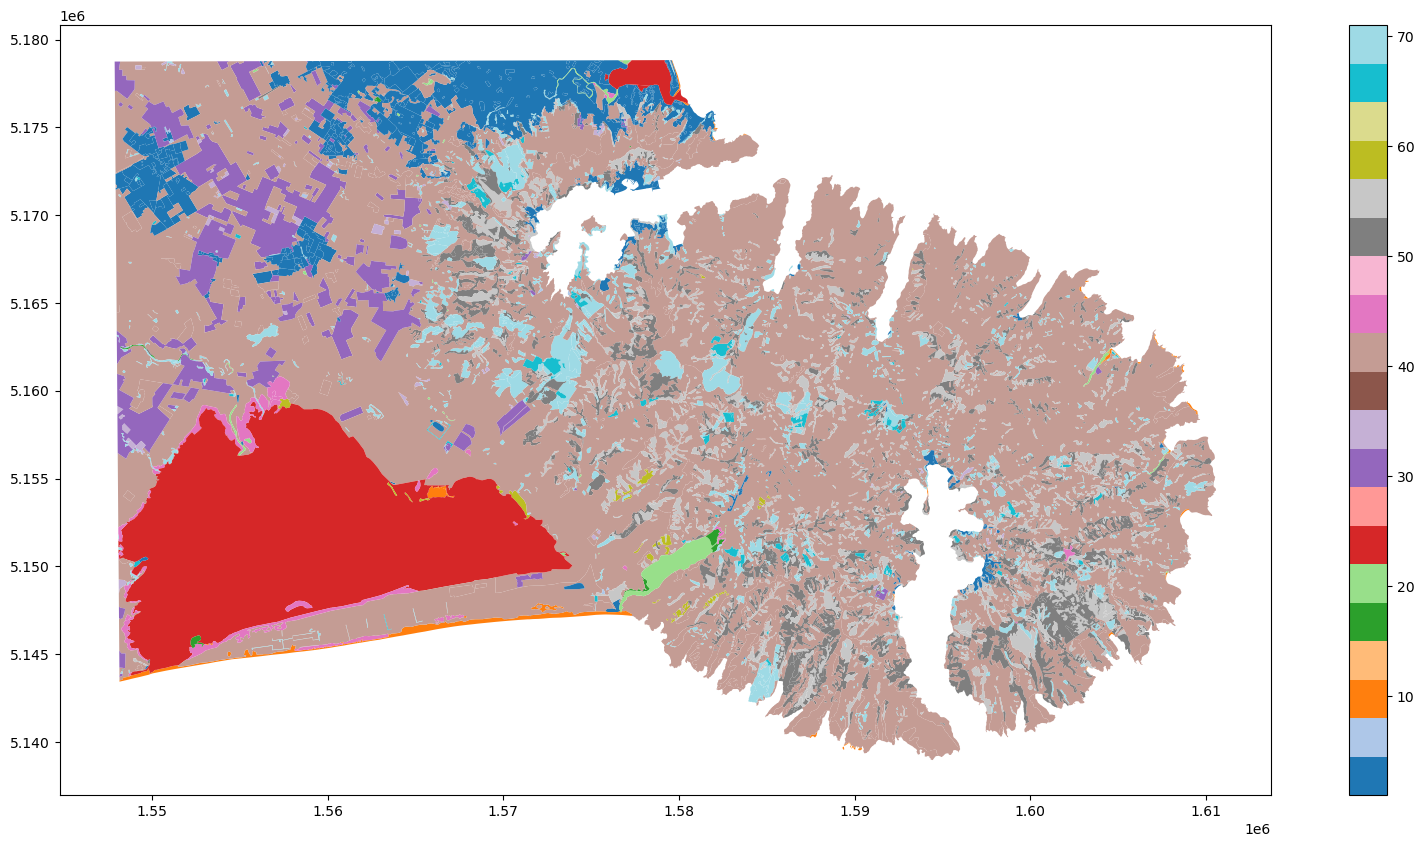

In [31]:
landcover.plot(column='Class_2023', cmap='tab20', legend=True, figsize=(20, 10))

<Axes: >

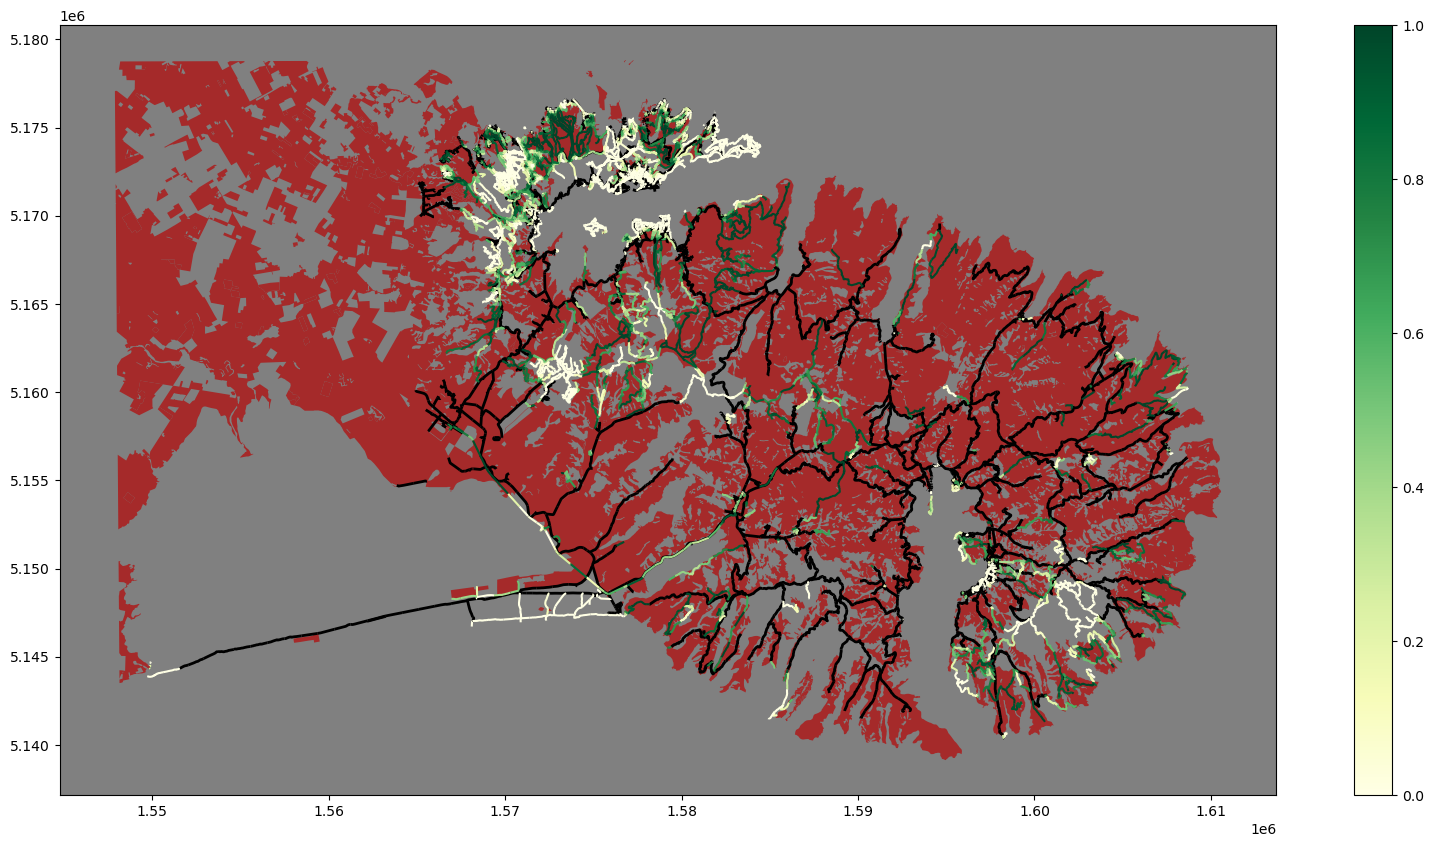

In [30]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.set_facecolor('grey')
road_features = strava_gwr_features_ped[strava_gwr_features_ped['road'] == True]
plot = road_features.plot(ax=ax, color='black', linewidth=2)
strava_gwr_features_ped[strava_gwr_features_ped['road'] == False].plot(column='High Producing Exotic Grassland_proportion', cmap='YlGn', legend=True, figsize=(20, 10), ax=ax)
landcover[landcover['Name_2023']=='High Producing Exotic Grassland'].plot(facecolor='brown', legend=True, figsize=(20, 10), ax=ax)